# 単線形回帰

### ライブラリのインポート

In [73]:
import numpy as np

# matplotlib と mpl_toolkits は必須ではないですが、グラフを書く際に必要となります。
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [74]:
# ランダムなデータの作成
observations = 100000

xs = np.random.uniform(low=-10, high=10, size=(observations, 1))

zs = np.random.uniform(-10, 10, (observations, 1))

inputs = np.column_stack((xs, zs))

print(inputs.shape)

(100000, 2)


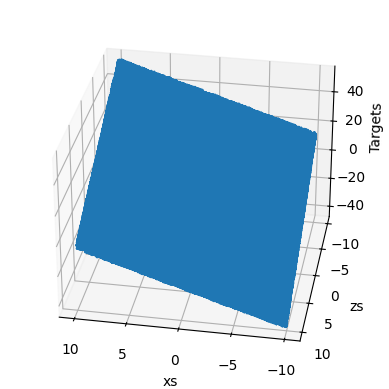

In [75]:
# ターゲットの作成
targets = 2 * xs - 3 * zs + 5 + np.random.uniform(-1, 1, (observations, 1))

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot(xs, zs, targets)

ax.set_xlabel("xs")
ax.set_ylabel("zs")
ax.set_zlabel("Targets")

ax.view_init(azim=100)
plt.show()

In [76]:
init_range = 0.1

# 2x1の行列を作成し、重みとバイアスを初期化
weights = np.random.uniform(-init_range, init_range, (2, 1))
biases = np.random.uniform(-init_range, init_range, 1)

weights, biases

(array([[-0.09410027],
        [ 0.09274309]]),
 array([-0.03974721]))

In [77]:
# 学習率の設定
learning_rate = 0.02

In [78]:
# モデルを訓練する
for i in range(300):
    output = np.dot(inputs, weights) + biases
    deltas = output - targets

    # 2で割るのは、deltasの要素数で割るため
    # observationsで割るのは、単位入力あたりのlossの値が欲しいため
    loss = np.sum(deltas**2) / 2 / observations

    deltas_scaled = deltas / observations

    # 重みとバイアスの更新
    # 転地行列を取得し、入力とdeltas_scaledをドット積する
    weights = weights - learning_rate * np.dot(inputs.T, deltas_scaled)
    biases = biases - learning_rate * np.sum(deltas_scaled)

    print(loss)

245.27258499496304
7462.262570504049
239069.69404668643
7667495.045968897
245925493.06359738
7887973943.929652
253010783022.28604
8115666636761.57
260328032079921.12
8350821486703794.0
2.6788534409094614e+17
8.593699400308966e+18
2.756911167893075e+20
8.844570672801914e+21
2.8375405011268216e+23
9.103715328308813e+24
2.9208315720458128e+26
9.371423474113416e+27
3.0068777581996935e+29
9.647995667870244e+30
3.0957758014813574e+32
9.933743298257862e+33
3.1876259306812112e+35
1.0228988979552408e+37
3.2825319885255788e+38
1.0534066960644215e+40
3.380601563363587e+41
1.0849323549017155e+43
3.481946125672663e+44
1.1175117550245516e+46
3.5866811695595545e+47
1.15118207235727e+49
3.694926359439572e+50
1.1859818254165018e+52
3.8068056820846933e+53
1.2219509242648806e+55
3.9224476042363483e+56
1.2591307212565084e+58
4.041985235987833e+59
1.297564063640289e+61
4.165556500146443e+62
1.3372953480881773e+64
4.293304307796205e+65
1.3783705772202726e+67
4.425376740288107e+68
1.4208374181990927e+70
4.56

/Users/yuramaru/.local/share/virtualenvs/data-science-V6qJD9yz/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/1w/52jfb36j6sg557p8z_gknglh0000gn/T/ipykernel_49526/427473387.py:8: RuntimeWarning: overflow encountered in square
  loss = np.sum(deltas ** 2) / 2 / observations


inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf
inf


In [79]:
# 重みとバイアスの出力
print(weights, biases)

[[-4.16336763e+225]
 [ 4.46911096e+226]] [-2.13053102e+223]


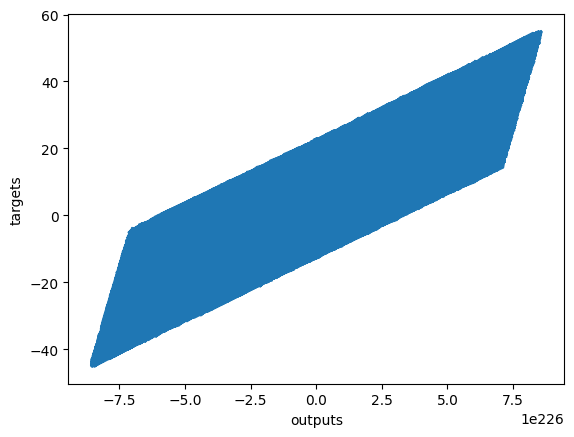

In [80]:
# ターゲットと出力のプロット
plt.plot(output, targets)
plt.xlabel("outputs")
plt.ylabel("targets")
plt.show()